### Column Consistency Check Across CSV Files

Before merging multiple CSV files into a single dataset, it is important to verify that all files share the same column structure. Differences in column names or ordering can lead to incorrect merging and introduce missing values.

The following code performs a column validation step:

1. All CSV files in the specified directory are located using the `glob` library.
2. The column names from the first CSV file are used as the reference schema.
3. For each remaining file, only the header (column names) is read using `pandas.read_csv()` with `nrows=0`, which avoids loading the full dataset into memory.
4. The column structure of each file is compared with the reference columns.
5. A message is printed indicating whether the columns match or if a mismatch is detected.

This approach ensures structural consistency across all datasets before concatenating them into a single dataframe.

In [1]:
import pandas as pd
import glob

files = glob.glob(r"C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\*.csv") # Locates all the csv files in the specified directory

base_columns = pd.read_csv(files[0], nrows=0).columns

for file in files[1:]:
    current_columns = pd.read_csv(file, nrows=0).columns
    
    if not base_columns.equals(current_columns):
        print(f"Column mismatch found in {file}")
    else:
        print(f"{file} columns match")

C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Friday-WorkingHours-Morning.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Monday-WorkingHours.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Tuesday-WorkingHours.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Wednesday-workingHours.pcap_ISCX.csv columns match


### Detecting Negative Values in Numeric Features

This code iterates through all CSV files in the dataset directory and checks for the presence of negative values in numeric columns.

First, each CSV file is loaded into a temporary pandas DataFrame. To ensure accurate datatype inference, the `low_memory=False` parameter is used when reading the file.

Next, only numeric columns are selected using the `select_dtypes()` function. This step is important because negative values are meaningful only for numeric data and not for categorical or textual features.

The code then evaluates whether any values in these numeric columns are less than zero. A boolean comparison (`numeric_df < 0`) is performed, and the resulting True values are summed column-wise to count how many negative values appear in each column.

Columns that contain at least one negative value are filtered and stored. If such columns exist in the file, the script prints the file name along with the column names and the number of negative entries detected.

This process helps identify potential data quality issues, anomalies, or unexpected values within the dataset before further preprocessing or model training.

In [2]:
for file in files:  
    # Iterate through each CSV file path stored in the list "files"

    df_temp = pd.read_csv(file, low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()  # Removes leading and trailing spaces from column names
    # Read the current CSV file into a temporary pandas DataFrame
    # low_memory=False ensures pandas reads the file in one pass for correct datatype inference

    numeric_df = df_temp.select_dtypes(include='number')  
    # Select only the columns that contain numeric values (integers or floats)
    # This avoids checking negative values in non-numeric columns like text or IP addresses

    negative_counts = (numeric_df < 0).sum()  
    # Create a boolean dataframe where values < 0 are True
    # Then sum the True values column-wise to count how many negative values each column contains

    negative_columns = negative_counts[negative_counts > 0]  
    # Filter the results to keep only columns where the count of negative values is greater than zero

    if not negative_columns.empty:  
        # Check whether any columns with negative values were found

        print(f"\nNegative values in file: {file}")  
        # Print the name/path of the file where negative values were detected

        print(negative_columns)  
        # Display the column names along with the number of negative values detected


Negative values in file: C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Flow Duration                  2
Flow Bytes/s                   2
Flow Packets/s                 2
Flow IAT Mean                  2
Flow IAT Max                   2
Flow IAT Min                 108
Fwd IAT Min                    6
Init_Win_bytes_forward     32925
Init_Win_bytes_backward    88299
dtype: int64

Negative values in file: C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Flow Duration                 36
Flow Bytes/s                  36
Flow Packets/s                36
Flow IAT Mean                 36
Flow IAT Max                  36
Flow IAT Min                 176
Init_Win_bytes_forward     60210
Init_Win_bytes_backward    76942
dtype: int64

Negative values in file: C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Frida

### Merging Multiple CSV Files into a Single DataFrame and Cleaning Dataset Columns

This code combines multiple CSV files into a single DataFrame and performs essential column cleaning to ensure consistency and remove redundancy.

First, all CSV files are read and concatenated using `pd.concat()`. The `ignore_index=True` parameter ensures that the row indices are reset, creating a continuous index across the merged dataset.

Next, column names are cleaned by removing any leading or trailing whitespace using `str.strip()`. This prevents issues caused by inconsistent formatting in column headers.

Since the dataset may contain duplicate columns, Pandas automatically appends suffixes such as `.1`, `.2`, etc., to make column names unique during loading. These suffixes are removed using a regular expression so that logically identical columns can be identified.

Finally, duplicate columns are removed by retaining only the first occurrence of each column name using `df.loc[:, ~df.columns.duplicated()]`. This step ensures that redundant features are eliminated, resulting in a cleaner and more reliable dataset.

The `df.info()` function is then used to display a concise summary of the DataFrame, including column names, data types, and non-null counts, while `df.head()` provides a preview of the first few rows for inspection.

In [3]:
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True) # Reads each csv file and concatenates them into a single dataframe, ignoring the original index
df.columns = df.columns.str.strip()  # Removes leading and trailing spaces from column names
df.columns = df.columns.str.replace(r'\.\d+$', '', regex=True) # Removes suffixes like '.1', '.2', etc. from column names (added by pandas for duplicate columns),
# so that logically identical columns can be recognized and handled properly
df = df.loc[:, ~df.columns.duplicated()] # Removes duplicate columns by keeping only the first occurence of each column name

In [4]:
df.info() # Displays a concise summary of the DataFrame
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 78 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow IAT Mi

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


**Pre-check for clean up** <br>
Grouping the dataset by the Label column to calculate the number of missing values for each feature within each class. Then filtering out columns with no missing values to focus only on relevant features. This helps understand how missing data is distributed across different categories (e.g., benign vs attack).

In [5]:
missing_by_label = df.groupby("Label").apply(lambda x: x.isna().sum())

# Filter only columns with missing values
missing_by_label = missing_by_label.loc[:, missing_by_label.sum() > 0]

print(missing_by_label)

missing = df.isna().sum()

                            Flow Bytes/s
Label                                   
BENIGN                               409
Bot                                    0
DDoS                                   0
DoS GoldenEye                          0
DoS Hulk                             949
DoS Slowhttptest                       0
DoS slowloris                          0
FTP-Patator                            0
Heartbleed                             0
Infiltration                           0
PortScan                               0
SSH-Patator                            0
Web Attack � Brute Force               0
Web Attack � Sql Injection             0
Web Attack � XSS                       0


### Handling Negative Values in TCP Window Size Features

During exploratory data analysis, the features **`Init_Win_bytes_forward`** and **`Init_Win_bytes_backward`** were found to contain a large number of negative values. These variables represent the initial TCP window size advertised by the client and the server during the establishment of a TCP connection. Since TCP window sizes represent the number of bytes that can be received before an acknowledgment is required, these values cannot be negative in practice.

In the CICIDS dataset, negative values (commonly `-1`) typically indicate that the TCP window size information was **missing, unavailable, or not applicable** for a particular flow. This situation can occur when only one direction of the flow was captured, when the flow was not based on the TCP protocol, or when the feature extraction process could not determine the window size.

Because these two columns contained **a very large number of negative values**, removing all rows with such entries would have resulted in the loss of a substantial portion of the dataset and could potentially bias the analysis or reduce the effectiveness of the machine learning model. Therefore, instead of dropping those rows, negative values were replaced with **0** using the `clip(lower=0)` function. This transformation ensures that invalid negative values are corrected while preserving the dataset size and maintaining logical consistency in the features.


In [6]:
df['Init_Win_bytes_forward'] = df['Init_Win_bytes_forward'].clip(lower=0)
df['Init_Win_bytes_backward'] = df['Init_Win_bytes_backward'].clip(lower=0)

### Removing Rows with Negative Values and Analyzing Label Distribution

This code performs data cleaning by removing rows that contain negative values in any numeric column and then analyzes the distribution of labels in the dataset.

First, the total number of rows in the dataset is stored in the variable `before`. A filtering condition is then applied to retain only those rows where all numeric features are greater than or equal to zero. This is achieved by selecting numeric columns, checking for non-negative values, and ensuring that the condition holds true across each row.

After filtering, the updated number of rows is stored in the variable `after`. The difference between `before` and `after` gives the total number of rows removed due to invalid negative values, which is printed for reference.

Finally, the distribution of the target variable (`Label`) is examined using `value_counts()`. This provides the frequency of each class in the cleaned dataset, helping to understand class balance and the impact of data cleaning on different categories.

In [7]:
before = len(df)
df = df[(df.select_dtypes(include='number') >= 0).all(axis=1)]
after = len(df)
print(f"Rows removed: {before - after}")
df['Label'].value_counts()

Rows removed: 4283


Label
BENIGN                        2269957
DoS Hulk                       229965
PortScan                       158930
DDoS                           128008
DoS GoldenEye                   10288
FTP-Patator                      7934
SSH-Patator                      5895
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       35
Web Attack � Sql Injection         21
Heartbleed                          7
Name: count, dtype: int64

In [8]:
import numpy as np
numeric_df = df.select_dtypes(include=[np.number])
inf_mask = np.isinf(numeric_df).any(axis=1) # Creating a boolean mask where True indicates row contains infinite values
inf_count = np.isinf(numeric_df).sum()

# Show only columns where inf exists
inf_count = inf_count[inf_count > 0]

print("\nCount of infinite values per column:")
print(inf_count)

# Remove rows with infinite values
df = df[~inf_mask]


Count of infinite values per column:
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


**Post-check for clean up** <br>
Grouping the dataset by the Label column to calculate the number of missing values for each feature within each class. Then filtering out columns with no missing values to focus only on relevant features. This helps understand how missing data is distributed across different categories (e.g., benign vs attack).

In [10]:
missing_by_label = df.groupby("Label").apply(lambda x: x.isna().sum())

# Filter only columns with missing values
missing_by_label = missing_by_label.loc[:, missing_by_label.sum() > 0]

if missing_by_label.empty:
    print("No missing values found in any column after filtering.")
else:
    print(missing_by_label)

# Filter rows containing infinite values

numeric_df = df.select_dtypes(include=[np.number])
inf_count = np.isinf(numeric_df).sum()

# Show only columns where inf exists
inf_count = inf_count[inf_count > 0]

if inf_count.empty:
    print("No infinite values found in any column after filtering.")
else:
    print("\nCount of infinite values per column:")
    print(inf_count)


No missing values found in any column after filtering.
No infinite values found in any column after filtering.


## Distribution of Network Traffic Labels

The below visualization represents the distribution of different network traffic categories in the dataset using a horizontal count plot.

### Key Observations:

- The dataset is **highly imbalanced**, with **BENIGN traffic dominating** the dataset by a very large margin.
- Among attack types, **DoS Hulk**, **PortScan**, and **DDoS** have relatively higher occurrences compared to others.
- Several attack categories such as:
  - Heartbleed  
  - SQL Injection  
  - Infiltration  
  - Web Attacks (XSS, Brute Force)  
  have **extremely low sample counts**.

### Interpretation:

- The imbalance indicates that a model trained directly on this dataset may become **biased toward predicting the majority class (BENIGN)**.
- Rare attack types may be **poorly learned or completely ignored** by the model.

### Implications for Modeling:

- This imbalance motivates the need for:
  - Reformulating the problem as **binary classification (BENIGN vs ATTACK)**

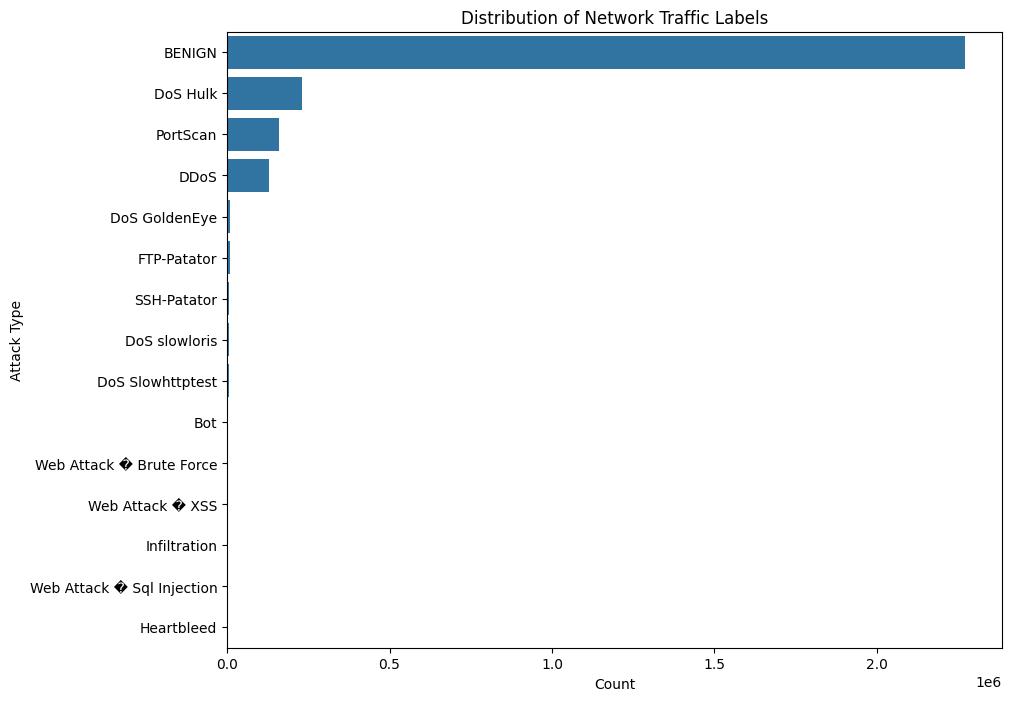

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
order = df["Label"].value_counts().index # Retrieving the unique labels sorted by their frequency

plt.figure(figsize=(10,8))
sns.countplot(data=df, y="Label", order=order)

plt.title("Distribution of Network Traffic Labels")
plt.xlabel("Count")
plt.ylabel("Attack Type")

plt.show()

## Feature Selection using Correlation Analysis

In this step, feature selection was performed to reduce redundancy and improve model efficiency.

### Approach:

1. **Correlation Matrix Computation**
   - Only numerical features were selected from the dataset.
   - A correlation matrix was computed to measure the relationship between each pair of features.

2. **Removing Duplicate Relationships**
   - Only the **upper triangle** of the correlation matrix was considered to avoid duplicate feature pairs.

3. **Identifying Highly Correlated Features**
   - A threshold of **0.95** was used.
   - Feature pairs with correlation greater than this threshold were considered highly correlated.
   - A total of **57 highly correlated pairs** were identified.

4. **Feature Reduction**
   - From each highly correlated pair, one feature was removed to eliminate redundancy.
   - This resulted in:
     - **25 features removed**
     - **52 features retained**

5. **Final Dataset Creation**
   - A reduced dataset (`df_selected`) was created using the selected features along with the target variable (`Label`).

### Results:

- **Original dataset shape:** (2,826,460, 78)
- **Reduced dataset shape:** (2,826,460, 53)

### Interpretation:

- Many features in the dataset were found to be **highly correlated or derived from each other**, indicating redundancy.
- Removing such features helps:
  - Reduce dimensionality  
  - Improve model training speed  
  - Minimize overfitting  
  - Enhance interpretability  

### Result:

Correlation-based feature selection effectively reduced the feature space while preserving the most informative attributes, preparing the dataset for efficient machine learning modeling.

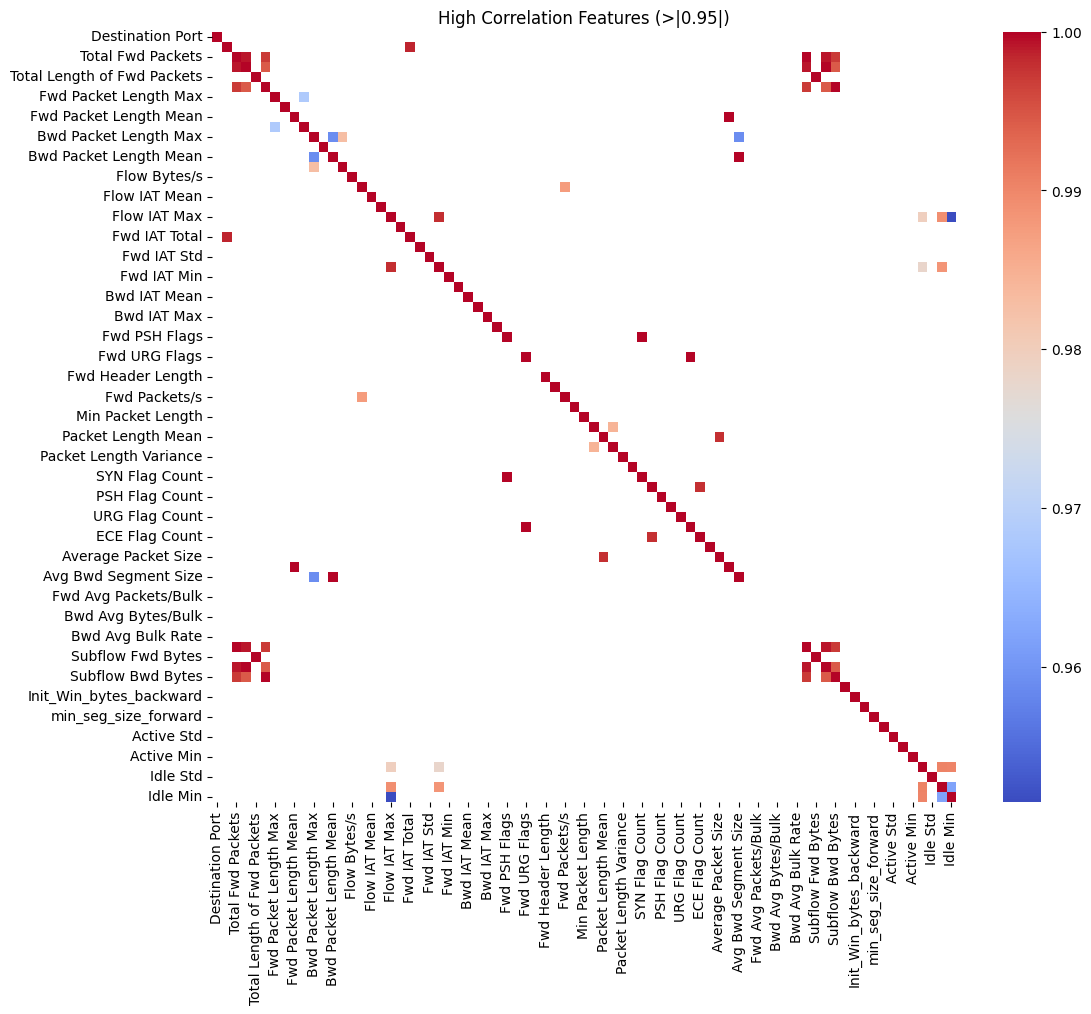

In [12]:
import numpy as np

numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

# Keep only strong correlations
threshold = 0.95
corr_filtered = corr[(np.abs(corr) > threshold)]

plt.figure(figsize=(12,10))
sns.heatmap(corr_filtered, cmap='coolwarm', annot=False)
plt.title("High Correlation Features (>|0.95|)")
plt.show()

In [13]:
# Step 1: Compute correlation
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

# Step 2: Take upper triangle only (avoid duplicates)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Step 3: Find highly correlated pairs
threshold = 0.95

high_corr_pairs = [
    (col1, col2, upper.loc[col1, col2])
    for col1 in upper.columns
    for col2 in upper.columns
    if abs(upper.loc[col1, col2]) > threshold
]

# Step 4: Print results
for col1, col2, corr_value in high_corr_pairs:
    print(f"{col1}  ↔  {col2}  →  {corr_value:.2f}")

# Step 5: Find columns to DROP

to_drop = [
    col for col in upper.columns
    if any(abs(upper[col]) > threshold)
]

# Step 6: Columns to KEEP
selected_columns = [col for col in numeric_df.columns if col not in to_drop]

print(f"\nTotal highly correlated pairs (>|{threshold}|): {len(high_corr_pairs)}")
print(f"Columns to drop: {len(to_drop)}")
print(f"Columns to keep: {len(selected_columns)}")
print("\nSelected columns are given below :")
for col in selected_columns:
    print(col)

# Step 7 : Feature selection using correlation threshold
df_selected = df[selected_columns + ["Label"]]
print(f"\nOriginal dataset shape: {df.shape}")
print(f"Selected dataset shape: {df_selected.shape}")

Flow Duration  ↔  Fwd IAT Total  →  1.00
Total Fwd Packets  ↔  Total Backward Packets  →  1.00
Total Fwd Packets  ↔  Total Length of Bwd Packets  →  1.00
Total Fwd Packets  ↔  Subflow Fwd Packets  →  1.00
Total Fwd Packets  ↔  Subflow Bwd Packets  →  1.00
Total Fwd Packets  ↔  Subflow Bwd Bytes  →  1.00
Total Backward Packets  ↔  Total Length of Bwd Packets  →  0.99
Total Backward Packets  ↔  Subflow Fwd Packets  →  1.00
Total Backward Packets  ↔  Subflow Bwd Packets  →  1.00
Total Backward Packets  ↔  Subflow Bwd Bytes  →  0.99
Total Length of Fwd Packets  ↔  Subflow Fwd Bytes  →  1.00
Total Length of Bwd Packets  ↔  Subflow Fwd Packets  →  1.00
Total Length of Bwd Packets  ↔  Subflow Bwd Packets  →  0.99
Total Length of Bwd Packets  ↔  Subflow Bwd Bytes  →  1.00
Fwd Packet Length Max  ↔  Fwd Packet Length Std  →  0.97
Fwd Packet Length Mean  ↔  Avg Fwd Segment Size  →  1.00
Bwd Packet Length Max  ↔  Bwd Packet Length Mean  →  0.96
Bwd Packet Length Max  ↔  Bwd Packet Length Std  →  0

### Binary Label Encoding for Intrusion Detection

The original dataset contains multiple traffic categories, including one normal class (`BENIGN`) and several attack classes (e.g., DoS, DDoS, PortScan, etc.). Since the objective of this project is to build a Network Intrusion Detection System (IDS) that distinguishes between normal and malicious traffic, the multi-class labels are transformed into a binary classification problem.

In this transformation:
- `BENIGN` traffic is encoded as **0** (normal behavior)
- All other categories are grouped and encoded as **1** (attack traffic)

To ensure robustness, the label values are cleaned using string operations (`strip` and `upper`) to handle inconsistencies such as extra spaces or variations in letter casing.

This binary encoding simplifies the modeling process, aligns with real-world IDS use cases (attack vs normal detection), and enables the application of both supervised and unsupervised machine learning algorithms effectively.

In [ ]:
import numpy as np

df["Traffic_Label"] = np.where(
    df["Label"].str.strip().str.upper() == "BENIGN",
    0,
    1
)
print("0 = Benign, 1 = Attack")
print(df["Traffic_Label"].value_counts())

Traffic_Label
0    2271320
1     556556
Name: count, dtype: int64


### Train-Test Split and Handling Class Imbalance

The dataset used in this project exhibits a significant class imbalance, where benign (normal) traffic instances greatly outnumber attack (malicious) instances. Such imbalance can bias machine learning models toward the majority class, leading to poor detection performance for minority (attack) classes, which is critical in an intrusion detection system.

To address this issue, the dataset is first divided into training and testing sets using stratified sampling. Stratification ensures that both sets preserve the original class distribution, allowing the test set to reflect real-world network traffic conditions and provide an unbiased evaluation of model performance.

After splitting, only the training data is used for balancing. This is important to avoid data leakage and ensure that the model is evaluated on realistic, imbalanced data. The training data is then balanced using undersampling, where the majority class (benign traffic) is randomly reduced to match the number of samples in the minority class (attack traffic).

The balanced training dataset enables the model to learn patterns from both classes equally, improving its ability to detect malicious traffic without being biased toward normal traffic. The dataset is then shuffled to remove any ordering bias before being used for model training.

This approach ensures a fair learning process while maintaining a realistic evaluation setup for intrusion detection performance.

In [28]:

## Train test split is being done here
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Label", "Traffic_Label"])
y = df["Traffic_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Combining train data for sampling
train_df = X_train.copy()
train_df["Traffic_Label"] = y_train

# Undersampling the majority class benign to balance the dataset

df_benign = train_df[train_df["Traffic_Label"] == 0]
df_attack = train_df[train_df["Traffic_Label"] == 1]

df_sampled = df_benign.sample(n=len(df_attack), random_state=42)

train_balanced = pd.concat([df_sampled, df_attack]).sample(frac=1, random_state=42)  # Shuffle the balanced dataset

print(train_balanced["Traffic_Label"].value_counts())

Traffic_Label
0    445202
1    445202
Name: count, dtype: int64


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Prepare training data

X_train_bal = train_balanced.drop(columns=["Traffic_Label"])
y_train_bal = train_balanced["Traffic_Label"]

# Step 2: Define Random Forest

rf = RandomForestClassifier(random_state=42, n_jobs=-1) # Use all CPU cores for faster training

# Step 3: Hyperparameter Grid

param_grid = {
    "n_estimators": [100, 200], # Number of trees
    "max_depth": [10, 20, None], # Maximum depth of each tree
    "min_samples_split": [2, 5], # Minimum samples needed to split a node
    "min_samples_leaf": [1, 2] #minimum samples in leaf node
}

# Step 4: Cross Validation Setup

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 5: Grid Search

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_bal, y_train_bal)

# Step 6: Best Model

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

# Step 7: Feature Importance

importances = best_rf.feature_importances_
feature_names = X_train_bal.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Select Top 15 features
top_features = feature_importance_df.head(15)["Feature"].tolist()

print("Top Features:", top_features)

# Step 8: Train Again on Selected Features

X_train_top = X_train_bal[top_features]
X_test_top = X_test[top_features]

best_rf.fit(X_train_top, y_train_bal)

# Step 9: Evaluate on Test Data

y_pred = best_rf.predict(X_test_top)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


ValueError: 
All the 120 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\kalyan_developer\miniconda3\envs\aai\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kalyan_developer\miniconda3\envs\aai\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\kalyan_developer\miniconda3\envs\aai\Lib\site-packages\sklearn\ensemble\_forest.py", line 374, in fit
    estimator._compute_missing_values_in_feature_mask(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        X, es